# 04 — LTM Methodology Check

Este notebook é uma análise extra, separada do valuation oficial.

O objetivo é comparar a metodologia usada no projeto principal, baseada em **1T26 anualizado** (`resultado trimestral × 4`), com uma leitura alternativa em **LTM / trailing twelve months** quando essa informação estiver disponível.

This notebook is a methodological check, not a replacement for the base valuation. The official valuation remains in `02-relative-valuation.ipynb`; here we only test whether the conclusion changes materially under an LTM-style approach.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except Exception:
    YFINANCE_AVAILABLE = False

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load Current Project Outputs

Primeiro carregamos a base processada do notebook 01 e a base normalizada já usada no projeto.

The current model uses Brazilian companies on a 1Q26 annualized basis and LatAm peers mostly from trailing market data. This already creates an important methodological point: the Brazilian companies and the external peers are not perfectly aligned on the same earnings basis.

In [2]:
processed_path = Path("../data/processed/master_valuation_dataset.csv")
normalized_path = Path("../data/processed/normalized_valuation_base.csv")
scenarios_path = Path("../outputs/gmat3_relative_valuation_scenarios.csv")

valuation_df = pd.read_csv(processed_path)
normalized_df = pd.read_csv(normalized_path)
scenarios_df = pd.read_csv(scenarios_path)

valuation_df

,ticker,company,sector,subsector,period,report_date,currency,revenue,ebitda,ebit,net_income,cash,total_debt,shares_outstanding,net_revenue_growth_yoy_pct,net_income_growth_yoy_pct,same_store_sales_growth_pct,gross_margin_pct,ebitda_margin_pre_ifrs16_pct,ebitda_margin_post_ifrs16_pct,ebitda_pre_ifrs16_mn,ebitda_post_ifrs16_mn,operational_comment,valuation_date,current_price,market_cap,market_cap_mn,net_debt,enterprise_value,ebitda_annualized,ev_ebitda_annualized
0,GMAT3.SA,Grupo Mateus,Consumer Staples,Food Retail,1T26,2026-03-31,BRL,9402,400,NaN,213,1984,2720,"2,300,047,621.00",12.90,-21.80,-7.30,22.90,4.30,5.80,399.80,543.00,"1T26 impacted by food deflation, weaker demand...",2026-05-31,4.27,9821203456,"9,821.20",736,"10,557.20",1600,6.60
1,ASAI3.SA,Assai,Consumer Staples,Cash & Carry,1T26,2026-03-31,BRL,20600,1000,NaN,174,4366,16374,"1,353,531,000.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-31,8.75,11740311552,"11,740.31",12008,"23,748.31",4000,5.94
2,PCAR3.SA,GPA,Consumer Staples,Food Retail,1T26,2026-03-31,BRL,4374,458,NaN,-1347,943,4173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-31,1.86,915002432,915.00,3230,"4,145.00",1832,2.26


## 2. Current Annualized Methodology

Na metodologia atual, usamos o EBITDA trimestral do 1T26 multiplicado por 4.

Isso cria uma aproximação anual simples. Ela é útil quando o objetivo é fazer uma primeira leitura rápida, mas não captura a sazonalidade nem a evolução dos últimos quatro trimestres.

In other words: annualized 1Q26 is a shortcut; LTM is usually more robust because it uses the last twelve months actually reported.

In [3]:
annualized_methodology_df = valuation_df[[
    "ticker",
    "company",
    "current_price",
    "market_cap_mn",
    "net_debt",
    "enterprise_value",
    "ebitda",
    "ebitda_annualized",
    "ev_ebitda_annualized",
    "net_income",
    "shares_outstanding"
]].copy()

annualized_methodology_df["net_income_annualized"] = annualized_methodology_df["net_income"] * 4
annualized_methodology_df["pe_annualized"] = np.where(
    annualized_methodology_df["net_income_annualized"] > 0,
    annualized_methodology_df["market_cap_mn"] / annualized_methodology_df["net_income_annualized"],
    np.nan
)

annualized_methodology_df

,ticker,company,current_price,market_cap_mn,net_debt,enterprise_value,ebitda,ebitda_annualized,ev_ebitda_annualized,net_income,shares_outstanding,net_income_annualized,pe_annualized
0,GMAT3.SA,Grupo Mateus,4.27,"9,821.20",736,"10,557.20",400,1600,6.60,213,"2,300,047,621.00",852,11.53
1,ASAI3.SA,Assai,8.75,"11,740.31",12008,"23,748.31",1000,4000,5.94,174,"1,353,531,000.00",696,16.87
2,PCAR3.SA,GPA,1.86,915.00,3230,"4,145.00",458,1832,2.26,-1347,NaN,-5388,NaN


## 3. Optional Trailing / LTM Data from Yahoo Finance

Aqui tentamos buscar dados `trailing` pelo Yahoo Finance usando `yfinance`.

Se a internet ou o Yahoo Finance não retornarem alguma métrica, o notebook não quebra: ele apenas marca o dado como indisponível. Isso é importante porque bases públicas podem mudar, falhar ou retornar campos incompletos.

The key fields we try to collect are:

- enterprise value
- market cap
- trailing EBITDA
- trailing net income
- trailing P/E

All absolute market values are converted to **BRL millions** only for Brazilian tickers. For non-Brazilian peers, we use multiples directly because EV/EBITDA and P/E are currency-neutral ratios.

In [4]:
def safe_info_value(info, possible_keys):
    for key in possible_keys:
        value = info.get(key)
        if value is not None and not (isinstance(value, float) and np.isnan(value)):
            return value
    return np.nan


def fetch_yfinance_trailing_metrics(ticker):
    if not YFINANCE_AVAILABLE:
        return {
            "ticker": ticker,
            "data_source": "yfinance not available",
            "market_cap_abs": np.nan,
            "enterprise_value_abs": np.nan,
            "trailing_ebitda_abs": np.nan,
            "trailing_net_income_abs": np.nan,
            "ev_ebitda_ltm": np.nan,
            "pe_ltm": np.nan,
        }

    try:
        ticker_obj = yf.Ticker(ticker)
        info = ticker_obj.info or {}

        market_cap_abs = safe_info_value(info, ["marketCap"])
        enterprise_value_abs = safe_info_value(info, ["enterpriseValue"])
        trailing_ebitda_abs = safe_info_value(info, ["ebitda"])
        trailing_net_income_abs = safe_info_value(info, ["netIncomeToCommon", "netIncome"])
        trailing_pe = safe_info_value(info, ["trailingPE"])

        ev_ebitda_ltm = (
            enterprise_value_abs / trailing_ebitda_abs
            if pd.notna(enterprise_value_abs) and pd.notna(trailing_ebitda_abs) and trailing_ebitda_abs > 0
            else np.nan
        )

        pe_ltm = (
            market_cap_abs / trailing_net_income_abs
            if pd.notna(market_cap_abs) and pd.notna(trailing_net_income_abs) and trailing_net_income_abs > 0
            else trailing_pe
        )

        return {
            "ticker": ticker,
            "data_source": "yfinance trailing snapshot",
            "market_cap_abs": market_cap_abs,
            "enterprise_value_abs": enterprise_value_abs,
            "trailing_ebitda_abs": trailing_ebitda_abs,
            "trailing_net_income_abs": trailing_net_income_abs,
            "ev_ebitda_ltm": ev_ebitda_ltm,
            "pe_ltm": pe_ltm,
        }
    except Exception as error:
        return {
            "ticker": ticker,
            "data_source": f"yfinance error: {error}",
            "market_cap_abs": np.nan,
            "enterprise_value_abs": np.nan,
            "trailing_ebitda_abs": np.nan,
            "trailing_net_income_abs": np.nan,
            "ev_ebitda_ltm": np.nan,
            "pe_ltm": np.nan,
        }

all_tickers = normalized_df["ticker"].dropna().unique().tolist()
yfinance_ltm_df = pd.DataFrame([fetch_yfinance_trailing_metrics(ticker) for ticker in all_tickers])

yfinance_ltm_df

,ticker,data_source,market_cap_abs,enterprise_value_abs,trailing_ebitda_abs,trailing_net_income_abs,ev_ebitda_ltm,pe_ltm
0,GMAT3.SA,yfinance trailing snapshot,9821203456,15355474944,2517331968,1773538048,6.10,5.54
1,ASAI3.SA,yfinance trailing snapshot,11740311552,34419310592,5616999936,700000000,6.13,16.77
2,PCAR3.SA,yfinance trailing snapshot,915002432,8406584832,533000000,-1904999936,15.77,NaN
3,WALMEX.MX,yfinance trailing snapshot,907495276544,959297290240,97478295552,50073546752,9.84,18.12
4,CHDRAUIB.MX,yfinance trailing snapshot,94055096320,141098713088,19550976000,6545449984,7.22,14.37
5,SORIANAB.MX,yfinance trailing snapshot,61573902336,81359486976,10997213184,3442627072,7.40,17.89
6,CENCOSUD.SN,yfinance trailing snapshot,5780666843136,11398445793280,1049218449408,282358743040,10.86,20.47


## 4. Build a Comparable LTM View

Agora juntamos três leituras:

1. **1T26 anualizado** para as empresas brasileiras, já usado no projeto.
2. **Múltiplos trailing disponíveis localmente** para os pares LatAm.
3. **Tentativa de yfinance LTM** para todos os tickers, quando disponível.

A coluna mais importante aqui é `best_available_ev_ebitda_ltm`. Ela usa o dado trailing do Yahoo quando disponível; se não estiver disponível, usa o múltiplo trailing já salvo na base normalizada para os pares LatAm.

In [5]:
comparison_df = normalized_df[[
    "ticker",
    "company",
    "country",
    "peer_role",
    "peer_quality",
    "include_in_trading_comps",
    "ebitda_basis",
    "net_income_basis",
    "ev_ebitda_multiple",
    "pe_ratio",
    "pe_status",
    "multiple_source",
]].copy()

comparison_df = comparison_df.merge(yfinance_ltm_df, on="ticker", how="left")

comparison_df["annualized_or_saved_ev_ebitda"] = comparison_df["ev_ebitda_multiple"]
comparison_df["annualized_or_saved_pe"] = comparison_df["pe_ratio"]

saved_trailing_ev_ebitda = pd.Series(
    np.where(
        comparison_df["ebitda_basis"].str.contains("trailing", case=False, na=False),
        comparison_df["ev_ebitda_multiple"],
        np.nan,
    ),
    index=comparison_df.index,
)

saved_trailing_pe = pd.Series(
    np.where(
        comparison_df["net_income_basis"].str.contains("trailing", case=False, na=False),
        comparison_df["pe_ratio"],
        np.nan,
    ),
    index=comparison_df.index,
)

comparison_df["best_available_ev_ebitda_ltm"] = comparison_df["ev_ebitda_ltm"].combine_first(saved_trailing_ev_ebitda)
comparison_df["best_available_pe_ltm"] = comparison_df["pe_ltm"].combine_first(saved_trailing_pe)

comparison_df["ev_ebitda_methodology_gap"] = (
    comparison_df["best_available_ev_ebitda_ltm"] - comparison_df["annualized_or_saved_ev_ebitda"]
)

comparison_df[[
    "ticker",
    "company",
    "country",
    "peer_role",
    "ebitda_basis",
    "annualized_or_saved_ev_ebitda",
    "best_available_ev_ebitda_ltm",
    "ev_ebitda_methodology_gap",
    "annualized_or_saved_pe",
    "best_available_pe_ltm",
    "data_source",
]]

,ticker,company,country,peer_role,ebitda_basis,annualized_or_saved_ev_ebitda,best_available_ev_ebitda_ltm,ev_ebitda_methodology_gap,annualized_or_saved_pe,best_available_pe_ltm,data_source
0,GMAT3.SA,Grupo Mateus,Brazil,Target,1Q26 annualized,6.58,6.10,-0.48,11.50,5.54,yfinance trailing snapshot
1,ASAI3.SA,Assai,Brazil,Domestic Core Peer,1Q26 annualized,6.10,6.13,0.02,17.83,16.77,yfinance trailing snapshot
2,PCAR3.SA,GPA,Brazil,Domestic Distressed Peer,1Q26 annualized,2.30,15.77,13.47,NaN,NaN,yfinance trailing snapshot
3,WALMEX.MX,Walmart de Mexico,Mexico,LatAm Peer,yfinance trailing EBITDA,9.84,9.84,0.00,18.22,18.12,yfinance trailing snapshot
4,CHDRAUIB.MX,Grupo Comercial Chedraui,Mexico,LatAm Peer,yfinance trailing EBITDA,7.22,7.22,-0.00,14.39,14.37,yfinance trailing snapshot
5,SORIANAB.MX,Organizacion Soriana,Mexico,LatAm Peer,yfinance trailing EBITDA,7.40,7.40,0.00,12.70,17.89,yfinance trailing snapshot
6,CENCOSUD.SN,Cencosud,Chile,LatAm Peer,yfinance trailing EBITDA,10.86,10.86,-0.00,20.70,20.47,yfinance trailing snapshot


## 5. Recalculate GMAT3 Valuation Using an LTM-style Peer Median

Nesta etapa, não estamos mudando o valuation oficial. Estamos apenas perguntando:

> Se eu usar uma mediana baseada nos múltiplos LTM/trailing disponíveis, o preço justo muda muito?

Para manter a comparação limpa, usamos o mesmo EBITDA anualizado de GMAT3 como base operacional quando não houver EBITDA LTM oficial disponível. Se o Yahoo trouxer um múltiplo trailing confiável para GMAT3, ele aparece na comparação, mas o valuation abaixo continua sendo uma ponte metodológica simples.

Importante: se não houver dado LTM disponível para Assaí ou outros pares brasileiros, o teste LTM passa a ficar mais dependente dos pares LatAm externos. Isso aumenta a distância metodológica em relação ao valuation oficial e deve ser tratado como sensibilidade, não como novo preço-alvo.

In [6]:
target_ticker = "GMAT3.SA"

healthy_peer_mask = (
    comparison_df["include_in_trading_comps"].astype(str).str.lower().eq("true")
    & comparison_df["ticker"].ne("PCAR3.SA")
    & comparison_df["ticker"].ne(target_ticker)
)

healthy_ltm_multiples = comparison_df.loc[healthy_peer_mask, "best_available_ev_ebitda_ltm"].dropna()
current_project_multiples = comparison_df.loc[healthy_peer_mask, "annualized_or_saved_ev_ebitda"].dropna()

ltm_peer_median = healthy_ltm_multiples.median()
current_project_peer_median = current_project_multiples.median()

base_case_row = scenarios_df.loc[
    scenarios_df["scenario"].eq("Expanded LatAm ex-Distressed Median")
].iloc[0]

target_row = valuation_df.loc[valuation_df["ticker"].eq(target_ticker)].iloc[0]

target_ebitda_annualized = target_row["ebitda_annualized"]
target_net_debt = target_row["net_debt"]
target_shares_outstanding = target_row["shares_outstanding"]
target_current_price = target_row["current_price"]

ltm_included_peers = comparison_df.loc[
    healthy_peer_mask & comparison_df["best_available_ev_ebitda_ltm"].notna(),
    "ticker",
].tolist()

ltm_check_scenarios_df = pd.DataFrame({
    "scenario": ["Official Base Case", "LTM / Trailing Peer Median Check"],
    "applied_ev_ebitda_multiple": [base_case_row["applied_ev_ebitda_multiple"], ltm_peer_median],
    "peer_count": [base_case_row.get("peer_count", np.nan), len(ltm_included_peers)],
    "included_peers": [base_case_row.get("included_peers", ""), ", ".join(ltm_included_peers)],
    "methodology": [
        "Official project case: LatAm ex-distressed median from notebook 02",
        "Check case: median of available LTM/trailing EV/EBITDA for healthy peers; may exclude Brazilian peers if trailing data is unavailable",
    ],
})

ltm_check_scenarios_df["implied_enterprise_value"] = (
    target_ebitda_annualized * ltm_check_scenarios_df["applied_ev_ebitda_multiple"]
)
ltm_check_scenarios_df["implied_equity_value"] = (
    ltm_check_scenarios_df["implied_enterprise_value"] - target_net_debt
)
ltm_check_scenarios_df["implied_price_per_share"] = (
    ltm_check_scenarios_df["implied_equity_value"] * 1_000_000 / target_shares_outstanding
)
ltm_check_scenarios_df["upside_downside_pct"] = (
    ltm_check_scenarios_df["implied_price_per_share"] / target_current_price - 1
) * 100

ltm_check_scenarios_df

,scenario,applied_ev_ebitda_multiple,peer_count,included_peers,methodology,implied_enterprise_value,implied_equity_value,implied_price_per_share,upside_downside_pct
0,Official Base Case,7.40,5,"ASAI3.SA, CHDRAUIB.MX, SORIANAB.MX, WALMEX.MX,...",Official project case: LatAm ex-distressed med...,"11,836.80","11,100.80",4.83,13.03
1,LTM / Trailing Peer Median Check,7.40,5,"ASAI3.SA, WALMEX.MX, CHDRAUIB.MX, SORIANAB.MX,...",Check case: median of available LTM/trailing E...,"11,837.11","11,101.11",4.83,13.03


## 6. Read the Difference

Esta tabela mostra se a troca de metodologia muda muito a conclusão.

Se os preços justos ficarem próximos, a conclusão principal é mais robusta. Se a diferença for grande, significa que o valuation é sensível à escolha entre `1T26 × 4` e LTM/trailing.

In [7]:
official_price = ltm_check_scenarios_df.loc[
    ltm_check_scenarios_df["scenario"].eq("Official Base Case"),
    "implied_price_per_share"
].iloc[0]

ltm_check_price = ltm_check_scenarios_df.loc[
    ltm_check_scenarios_df["scenario"].eq("LTM / Trailing Peer Median Check"),
    "implied_price_per_share"
].iloc[0]

methodology_difference_df = pd.DataFrame({
    "metric": [
        "Official base multiple",
        "LTM/trailing check multiple",
        "Official fair price",
        "LTM/trailing check fair price",
        "Difference in fair price",
        "Difference in fair price (%)",
    ],
    "value": [
        base_case_row["applied_ev_ebitda_multiple"],
        ltm_peer_median,
        official_price,
        ltm_check_price,
        ltm_check_price - official_price,
        (ltm_check_price / official_price - 1) * 100,
    ]
})

methodology_difference_df

,metric,value
0,Official base multiple,7.40
1,LTM/trailing check multiple,7.40
2,Official fair price,4.83
3,LTM/trailing check fair price,4.83
4,Difference in fair price,0.00
5,Difference in fair price (%),0.00


## 7. Simple Visualization

O gráfico abaixo compara o preço justo do caso oficial com o preço justo do teste LTM/trailing.

This is not meant to create a new target price. It is only a visual way to check whether the conclusion changes materially.

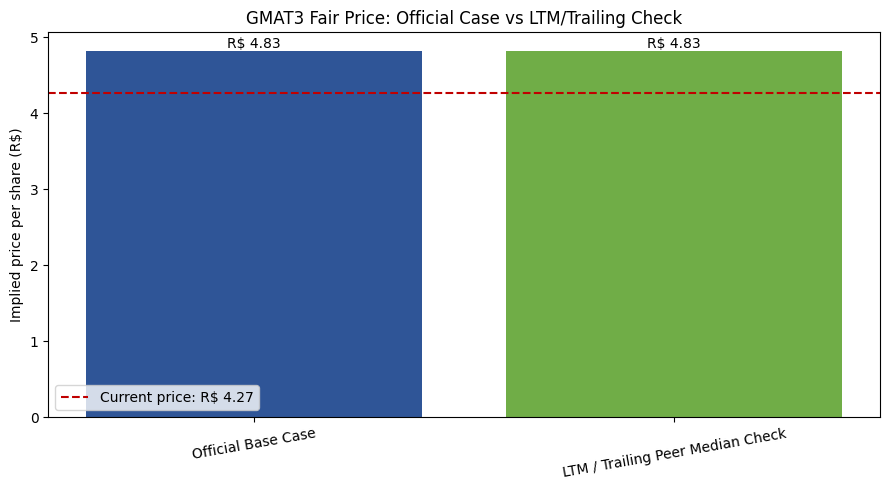

In [8]:
import matplotlib.pyplot as plt

charts_dir = Path("../charts")
charts_dir.mkdir(parents=True, exist_ok=True)

plot_df = ltm_check_scenarios_df.copy()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(plot_df["scenario"], plot_df["implied_price_per_share"], color=["#2F5597", "#70AD47"])
ax.axhline(target_current_price, color="#C00000", linestyle="--", linewidth=1.5, label=f"Current price: R$ {target_current_price:.2f}")
ax.set_title("GMAT3 Fair Price: Official Case vs LTM/Trailing Check")
ax.set_ylabel("Implied price per share (R$)")
ax.legend()
ax.tick_params(axis="x", rotation=10)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"R$ {height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig(charts_dir / "ltm_vs_annualized_fair_price_check.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Export Check Outputs

Salvamos os resultados em arquivos separados, sem sobrescrever os outputs principais.

This keeps the official valuation intact while preserving the LTM check for discussion and audit trail.

In [9]:
outputs_dir = Path("../outputs")
outputs_dir.mkdir(parents=True, exist_ok=True)

comparison_df.to_csv(outputs_dir / "ltm_methodology_peer_comparison.csv", index=False)
ltm_check_scenarios_df.to_csv(outputs_dir / "ltm_methodology_valuation_check.csv", index=False)
methodology_difference_df.to_csv(outputs_dir / "ltm_methodology_difference_summary.csv", index=False)

print("Saved:")
print(outputs_dir / "ltm_methodology_peer_comparison.csv")
print(outputs_dir / "ltm_methodology_valuation_check.csv")
print(outputs_dir / "ltm_methodology_difference_summary.csv")
print(charts_dir / "ltm_vs_annualized_fair_price_check.png")

Saved:
../outputs/ltm_methodology_peer_comparison.csv
../outputs/ltm_methodology_valuation_check.csv
../outputs/ltm_methodology_difference_summary.csv
../charts/ltm_vs_annualized_fair_price_check.png


## 9. Interpretation for the Report

Se a diferença entre o caso oficial e o teste LTM/trailing for pequena, podemos dizer que a tese é relativamente consistente mesmo mudando a base metodológica.

Se a diferença for grande, a leitura correta não é “o valuation está errado”, mas sim:

> O preço justo é sensível à normalização do EBITDA. Por isso, a versão final deveria priorizar EBITDA LTM auditável/extraído dos releases e manter `1T26 × 4` apenas como aproximação preliminar.

Para a apresentação, a frase mais defensável é:

> O método `1T26 × 4` é aceitável para uma primeira leitura, mas o LTM é mais robusto. Como o 1T26 de GMAT3 foi pressionado por SSS negativo, deflação alimentar e trade-off entre margem e volume, a anualização desse trimestre tende a carregar uma visão mais cautelosa da geração de resultado.